In [1]:
from pathlib import Path
import sys
import time
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.deep_learning.cnn_dataset as cnn_dataset
import src.deep_learning.cnn_model as cnn_model

In [2]:
DATA = PROJECT_ROOT / "data" / "processed"

MODELS = PROJECT_ROOT / "models"

RESULTS = PROJECT_ROOT / "results" / "reports"

RESULTS.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
X_test = pd.read_csv(
    DATA / "X_test_scaled.csv"
)

y_test = pd.read_csv(
    DATA / "y_test.csv"
)["Label"]

label_encoder = joblib.load(
    DATA / "label_encoder.pkl"
)

print("="*60)

print("Testing Samples :", len(X_test))

print()

print("Classes :", len(label_encoder.classes_))

print("="*60)

Testing Samples : 18000

Classes : 9


In [4]:
cnn_X_test = np.load(
    DATA / "cnn_X_test.npy"
)

cnn_y_test = np.load(
    DATA / "cnn_y_test.npy"
)

cnn_dataset_test = cnn_dataset.RadioMLDataset(
    cnn_X_test,
    cnn_y_test
)

cnn_loader = DataLoader(

    cnn_dataset_test,

    batch_size=64,

    shuffle=False,

    num_workers=0
)

In [5]:
rf = joblib.load(
    MODELS / "random_forest.pkl"
)

svm = joblib.load(
    MODELS / "svm.pkl"
)

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

cnn = cnn_model.CNNModel(
    num_classes=9
)

checkpoint = torch.load(

    MODELS / "cnn_best.pth",

    map_location=device

)

cnn.load_state_dict(
    checkpoint["model_state_dict"]
)

cnn.to(device)

cnn.eval()

print()

print("All Models Loaded Successfully")


All Models Loaded Successfully


In [6]:
rf_probabilities = rf.predict_proba(
    X_test
)

rf_predictions = np.argmax(

    rf_probabilities,

    axis=1

)

rf_confidence = np.max(

    rf_probabilities,

    axis=1

)

print()

print("Random Forest Completed")


Random Forest Completed


In [7]:
svm_probabilities = svm.predict_proba(
    X_test
)

svm_predictions = np.argmax(

    svm_probabilities,

    axis=1

)

svm_confidence = np.max(

    svm_probabilities,

    axis=1

)

print()

print("SVM Completed")


SVM Completed


In [8]:
cnn_predictions = []

cnn_confidence = []

cnn_probability = []

with torch.no_grad():

    for signals, labels in cnn_loader:

        signals = signals.to(device)

        outputs = cnn(signals)

        probability = torch.softmax(

            outputs,

            dim=1

        )

        probability = probability.cpu().numpy()

        prediction = np.argmax(

            probability,

            axis=1

        )

        confidence = np.max(

            probability,

            axis=1

        )

        cnn_predictions.extend(prediction)

        cnn_confidence.extend(confidence)

        cnn_probability.extend(probability)

cnn_predictions = np.array(cnn_predictions)

cnn_confidence = np.array(cnn_confidence)

cnn_probability = np.array(cnn_probability)

print()

print("CNN Completed")


CNN Completed


In [9]:
summary = pd.DataFrame({

    "Model":[

        "Random Forest",

        "SVM",

        "CNN"

    ],

    "Average Confidence":[

        rf_confidence.mean(),

        svm_confidence.mean(),

        cnn_confidence.mean()

    ],

    "Minimum Confidence":[

        rf_confidence.min(),

        svm_confidence.min(),

        cnn_confidence.min()

    ],

    "Maximum Confidence":[

        rf_confidence.max(),

        svm_confidence.max(),

        cnn_confidence.max()

    ]

})

summary

,Model,Average Confidence,Minimum Confidence,Maximum Confidence
0,Random Forest,0.932445,0.200000,1.0
1,SVM,0.950448,0.208431,1.0
2,CNN,0.993134,0.324983,1.0


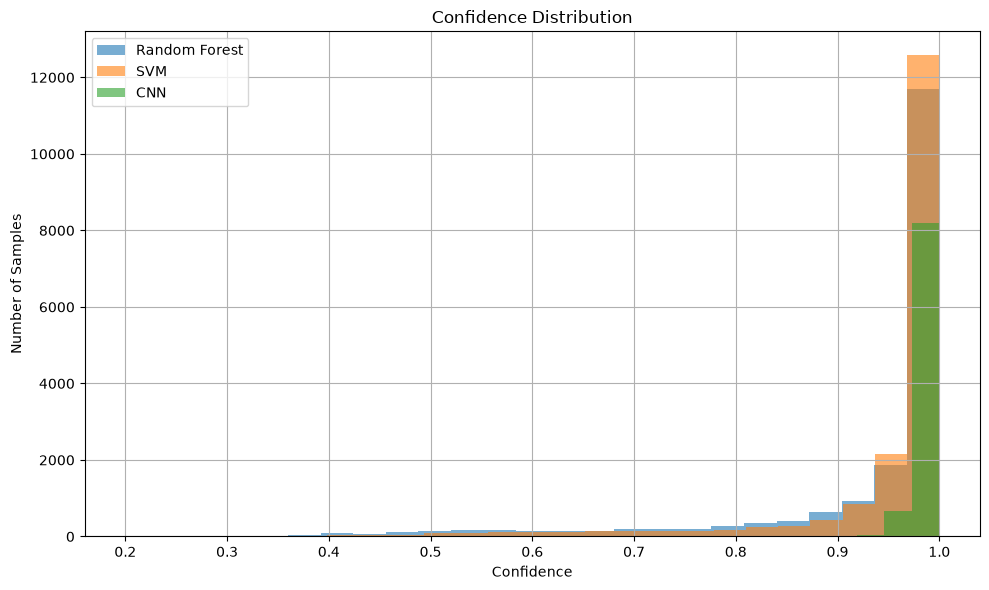

In [10]:
plt.figure(figsize=(10,6))

plt.hist(
    rf_confidence,
    bins=25,
    alpha=0.6,
    label="Random Forest"
)

plt.hist(
    svm_confidence,
    bins=25,
    alpha=0.6,
    label="SVM"
)

plt.hist(
    cnn_confidence,
    bins=25,
    alpha=0.6,
    label="CNN"
)

plt.xlabel("Confidence")

plt.ylabel("Number of Samples")

plt.title("Confidence Distribution")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [12]:
confidence_df = pd.DataFrame({

    "RF": pd.Series(rf_confidence),

    "SVM": pd.Series(svm_confidence),

    "CNN": pd.Series(cnn_confidence)

})

confidence_df.to_csv(

    RESULTS / "confidence_distribution.csv",

    index=False

)

print("Confidence Distribution Saved")

Confidence Distribution Saved


In [13]:
thresholds = np.arange(

    0.50,

    0.991,

    0.01

)

print("Thresholds Tested :", len(thresholds))

Thresholds Tested : 50


In [14]:
def evaluate_threshold(

    confidence,

    prediction,

    ground_truth,

    threshold

):
    """
    Evaluate unknown detection performance
    at a given confidence threshold.
    """

    accepted = confidence >= threshold

    rejected = ~accepted

    accepted_samples = accepted.sum()

    rejected_samples = rejected.sum()

    if accepted_samples == 0:

        return {

            "Threshold": threshold,

            "Accepted": 0,

            "Rejected": rejected_samples,

            "AcceptedAccuracy": 0,

            "RejectionRate": 1.0,

            "Precision": 0,

            "Recall": 0,

            "F1": 0

        }

    y_true = ground_truth[accepted]

    y_pred = prediction[accepted]

    accuracy = accuracy_score(

        y_true,

        y_pred

    )

    precision = precision_score(

        y_true,

        y_pred,

        average="weighted",

        zero_division=0

    )

    recall = recall_score(

        y_true,

        y_pred,

        average="weighted",

        zero_division=0

    )

    f1 = f1_score(

        y_true,

        y_pred,

        average="weighted",

        zero_division=0

    )

    return {

        "Threshold": threshold,

        "Accepted": accepted_samples,

        "Rejected": rejected_samples,

        "AcceptedAccuracy": accuracy,

        "RejectionRate": rejected_samples / len(ground_truth),

        "Precision": precision,

        "Recall": recall,

        "F1": f1

    }

In [15]:
rf_results = []

for threshold in thresholds:

    rf_results.append(

        evaluate_threshold(

            rf_confidence,

            rf_predictions,

            y_test.values,

            threshold

        )

    )

rf_results = pd.DataFrame(rf_results)

rf_results.head()

,Threshold,Accepted,Rejected,AcceptedAccuracy,RejectionRate,Precision,Recall,F1
0,0.50,17584,416,0.970883,0.023111,0.970915,0.970883,0.970830
1,0.51,17528,472,0.972045,0.026222,0.972092,0.972045,0.971999
2,0.52,17476,524,0.973449,0.029111,0.973504,0.973449,0.973407
3,0.53,17438,562,0.974309,0.031222,0.974359,0.974309,0.974266
4,0.54,17379,621,0.975373,0.034500,0.975428,0.975373,0.975331


In [16]:
svm_results = []

for threshold in thresholds:

    svm_results.append(

        evaluate_threshold(

            svm_confidence,

            svm_predictions,

            y_test.values,

            threshold

        )

    )

svm_results = pd.DataFrame(svm_results)

svm_results.head()

,Threshold,Accepted,Rejected,AcceptedAccuracy,RejectionRate,Precision,Recall,F1
0,0.50,17837,163,0.961204,0.009056,0.961211,0.961204,0.961118
1,0.51,17797,203,0.962241,0.011278,0.962257,0.962241,0.962158
2,0.52,17763,237,0.963238,0.013167,0.963254,0.963238,0.963156
3,0.53,17734,266,0.964024,0.014778,0.964037,0.964024,0.963939
4,0.54,17705,295,0.964812,0.016389,0.964836,0.964812,0.964737


In [17]:
cnn_results = []

for threshold in thresholds:

    cnn_results.append(

        evaluate_threshold(

            cnn_confidence,

            cnn_predictions,

            cnn_y_test,

            threshold

        )

    )

cnn_results = pd.DataFrame(cnn_results)

cnn_results.head()

,Threshold,Accepted,Rejected,AcceptedAccuracy,RejectionRate,Precision,Recall,F1
0,0.50,8995,5,0.991996,0.000556,0.992146,0.991996,0.992015
1,0.51,8994,6,0.992106,0.000667,0.992249,0.992106,0.992124
2,0.52,8993,7,0.992216,0.000778,0.992361,0.992216,0.992235
3,0.53,8992,8,0.992215,0.000889,0.992360,0.992215,0.992234
4,0.54,8989,11,0.992435,0.001222,0.992582,0.992435,0.992456


In [18]:
rf_results.to_csv(

    RESULTS / "rf_threshold_analysis.csv",

    index=False

)

svm_results.to_csv(

    RESULTS / "svm_threshold_analysis.csv",

    index=False

)

cnn_results.to_csv(

    RESULTS / "cnn_threshold_analysis.csv",

    index=False
)

print("Threshold Reports Saved")


Threshold Reports Saved


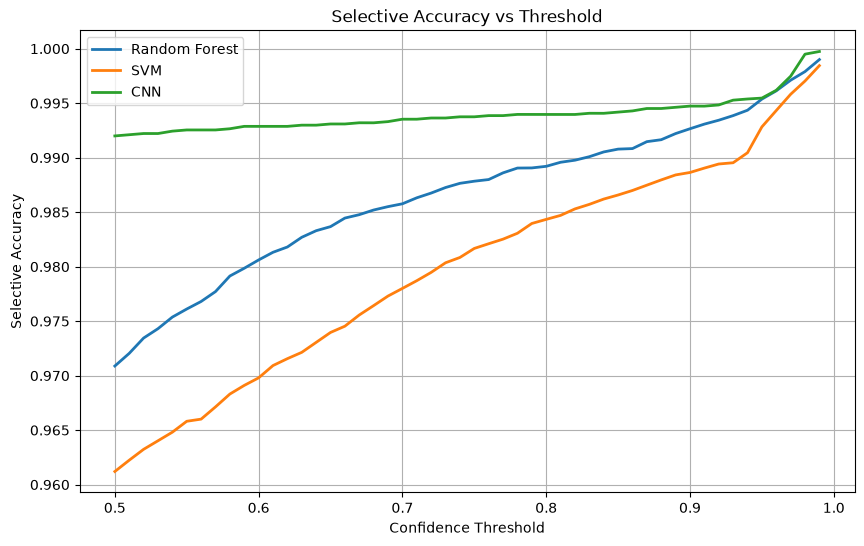

In [19]:
plt.figure(figsize=(10,6))

plt.plot(

    rf_results["Threshold"],

    rf_results["AcceptedAccuracy"],

    label="Random Forest",

    linewidth=2

)

plt.plot(

    svm_results["Threshold"],

    svm_results["AcceptedAccuracy"],

    label="SVM",

    linewidth=2

)

plt.plot(

    cnn_results["Threshold"],

    cnn_results["AcceptedAccuracy"],

    label="CNN",

    linewidth=2

)

plt.xlabel("Confidence Threshold")

plt.ylabel("Selective Accuracy")

plt.title("Selective Accuracy vs Threshold")

plt.grid(True)

plt.legend()

plt.show()

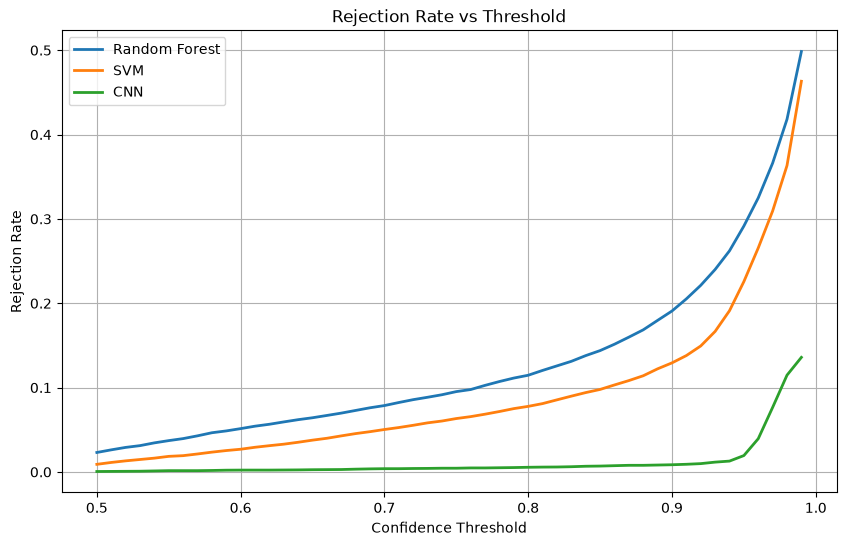

In [20]:
plt.figure(figsize=(10,6))

plt.plot(

    rf_results["Threshold"],

    rf_results["RejectionRate"],

    label="Random Forest",

    linewidth=2

)

plt.plot(

    svm_results["Threshold"],

    svm_results["RejectionRate"],

    label="SVM",

    linewidth=2

)

plt.plot(

    cnn_results["Threshold"],

    cnn_results["RejectionRate"],

    label="CNN",

    linewidth=2

)

plt.xlabel("Confidence Threshold")

plt.ylabel("Rejection Rate")

plt.title("Rejection Rate vs Threshold")

plt.grid(True)

plt.legend()

plt.show()

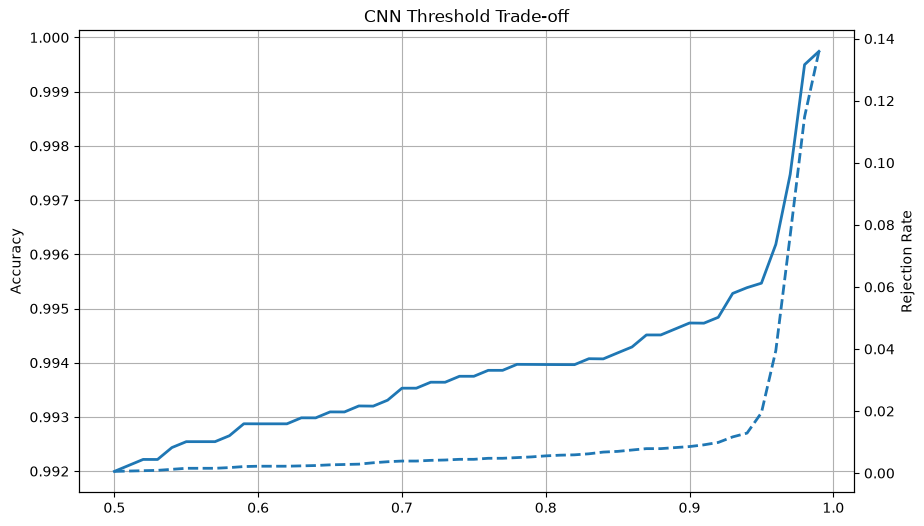

In [21]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(

    cnn_results["Threshold"],

    cnn_results["AcceptedAccuracy"],

    linewidth=2,

    label="Selective Accuracy"

)

ax1.set_ylabel("Accuracy")

ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(

    cnn_results["Threshold"],

    cnn_results["RejectionRate"],

    linestyle="--",

    linewidth=2,

    label="Rejection Rate"

)

ax2.set_ylabel("Rejection Rate")

plt.title("CNN Threshold Trade-off")

plt.show()

In [22]:
candidate = cnn_results[

    (cnn_results["AcceptedAccuracy"] >= 0.98)

    &

    (cnn_results["RejectionRate"] <= 0.10)

]

if len(candidate) > 0:

    best_threshold = candidate.sort_values(

        "Accepted",

        ascending=False

    ).iloc[0]

else:

    score = (

        cnn_results["AcceptedAccuracy"]

        -

        cnn_results["RejectionRate"]

    )

    best_threshold = cnn_results.iloc[score.idxmax()]

best_threshold

Threshold              0.500000
Accepted            8995.000000
Rejected               5.000000
AcceptedAccuracy       0.991996
RejectionRate          0.000556
Precision              0.992146
Recall                 0.991996
F1                     0.992015
Name: 0, dtype: float64

In [23]:
best = {

    "Recommended Threshold": float(

        best_threshold["Threshold"]

    ),

    "Accepted Accuracy": float(

        best_threshold["AcceptedAccuracy"]

    ),

    "Accepted Samples": int(

        best_threshold["Accepted"]

    ),

    "Rejected Samples": int(

        best_threshold["Rejected"]

    ),

    "Rejection Rate": float(

        best_threshold["RejectionRate"]

    )

}

with open(

    RESULTS / "best_threshold.json",

    "w"

) as file:

    json.dump(

        best,

        file,

        indent=4

    )

print("Best Threshold Saved")

Best Threshold Saved


In [24]:
# ==========================================================
# Mean Confidence per Modulation
# ==========================================================

confidence_per_class = pd.DataFrame({

    "Class": label_encoder.inverse_transform(cnn_y_test),

    "Confidence": cnn_confidence

})

class_confidence = (

    confidence_per_class

    .groupby("Class")

    .agg(

        MeanConfidence=("Confidence", "mean"),

        StdConfidence=("Confidence", "std"),

        Minimum=("Confidence", "min"),

        Maximum=("Confidence", "max")

    )

    .sort_values("MeanConfidence", ascending=False)

)

class_confidence

,MeanConfidence,StdConfidence,Minimum,Maximum
Class,,,,
GFSK,0.999757,0.006346,0.799345,1.000000
CPFSK,0.999569,0.007602,0.796049,1.000000
AM-DSB,0.999504,0.011838,0.625761,0.999979
BPSK,0.998873,0.009981,0.750737,0.999999
PAM4,0.996912,0.033244,0.384113,1.000000
QAM64,0.995496,0.035973,0.390402,1.000000
QPSK,0.992343,0.044953,0.491598,0.999999
8PSK,0.988606,0.056420,0.324983,1.000000
AM-SSB,0.967150,0.015063,0.783521,0.991789


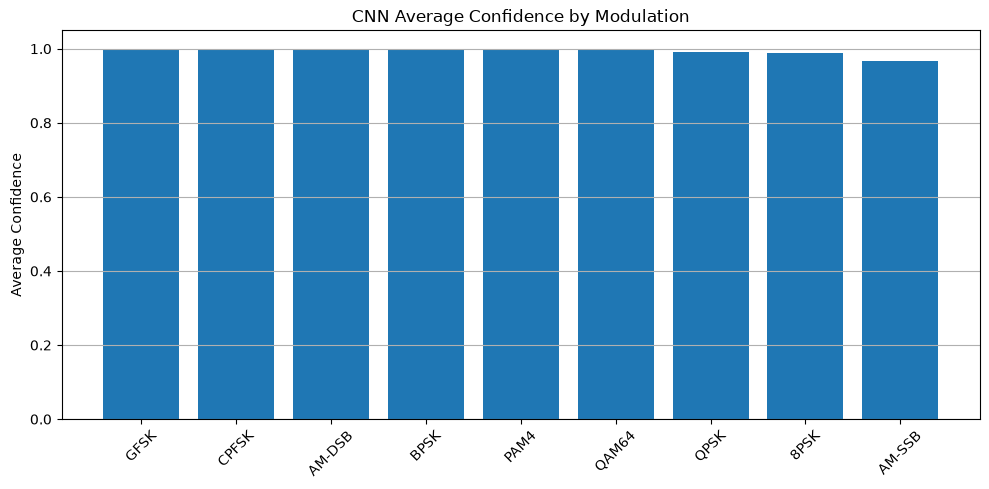

In [25]:
plt.figure(figsize=(10,5))

plt.bar(

    class_confidence.index,

    class_confidence["MeanConfidence"]

)

plt.xticks(rotation=45)

plt.ylabel("Average Confidence")

plt.title("CNN Average Confidence by Modulation")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [26]:
recommended_threshold = best_threshold["Threshold"]

accepted = cnn_confidence >= recommended_threshold

analysis = pd.DataFrame({

    "Class": label_encoder.inverse_transform(cnn_y_test),

    "Accepted": accepted

})

rejection_summary = (

    analysis

    .groupby("Class")

    .agg(

        Total=("Accepted", "count"),

        Accepted=("Accepted", "sum")

    )

)

rejection_summary["Rejected"] = (

    rejection_summary["Total"]

    - rejection_summary["Accepted"]

)

rejection_summary["Rejected (%)"] = (

    100 *

    rejection_summary["Rejected"]

    /

    rejection_summary["Total"]

)

rejection_summary

,Total,Accepted,Rejected,Rejected (%)
Class,,,,
8PSK,1000,998,2,0.2
AM-DSB,1000,1000,0,0.0
AM-SSB,1000,1000,0,0.0
BPSK,1000,1000,0,0.0
CPFSK,1000,1000,0,0.0
GFSK,1000,1000,0,0.0
PAM4,1000,999,1,0.1
QAM64,1000,999,1,0.1
QPSK,1000,999,1,0.1


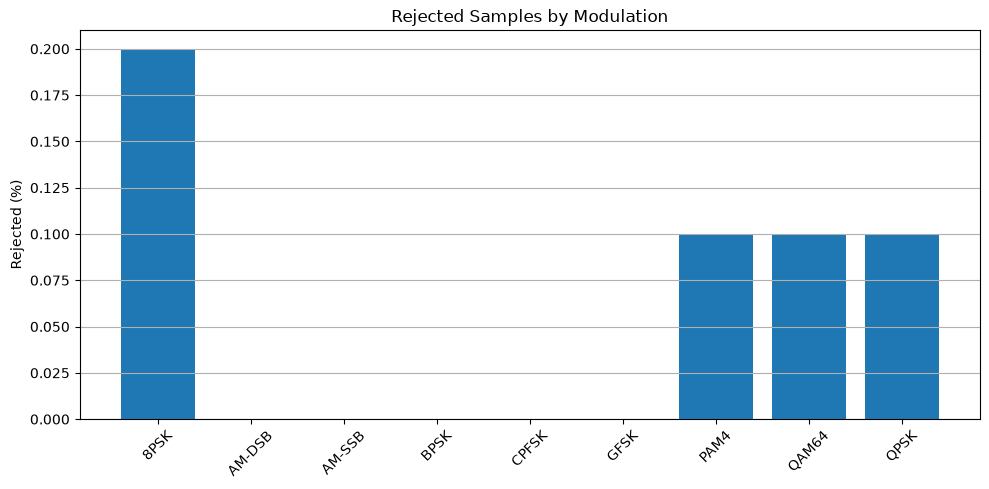

In [27]:
plt.figure(figsize=(10,5))

plt.bar(

    rejection_summary.index,

    rejection_summary["Rejected (%)"]

)

plt.xticks(rotation=45)

plt.ylabel("Rejected (%)")

plt.title("Rejected Samples by Modulation")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [28]:
example = pd.DataFrame({

    "Actual":

        label_encoder.inverse_transform(cnn_y_test),

    "Predicted":

        label_encoder.inverse_transform(cnn_predictions),

    "Confidence":

        cnn_confidence

})

example["Decision"] = np.where(

    example["Confidence"] >= recommended_threshold,

    "Known",

    "Unknown"

)

example.sample(20, random_state=42)

,Actual,Predicted,Confidence,Decision
7940,AM-SSB,AM-SSB,0.970308,Known
1162,GFSK,GFSK,0.999996,Known
582,BPSK,BPSK,0.999923,Known
4081,GFSK,GFSK,0.999997,Known
8412,CPFSK,CPFSK,0.999998,Known
8730,CPFSK,CPFSK,0.999998,Known
5936,8PSK,8PSK,0.940721,Known
8283,PAM4,PAM4,0.999991,Known
3706,BPSK,BPSK,0.999949,Known
4071,GFSK,GFSK,0.999798,Known


In [29]:
threshold = recommended_threshold

rf_best = rf_results.loc[
    rf_results["Threshold"] == threshold
].iloc[0]

svm_best = svm_results.loc[
    svm_results["Threshold"] == threshold
].iloc[0]

cnn_best = cnn_results.loc[
    cnn_results["Threshold"] == threshold
].iloc[0]

comparison = pd.DataFrame({

    "Model":[

        "Random Forest",

        "SVM",

        "CNN"

    ],

    "Accepted Accuracy":[

        rf_best["AcceptedAccuracy"],

        svm_best["AcceptedAccuracy"],

        cnn_best["AcceptedAccuracy"]

    ],

    "Rejection Rate":[

        rf_best["RejectionRate"],

        svm_best["RejectionRate"],

        cnn_best["RejectionRate"]

    ],

    "Accepted Samples":[

        rf_best["Accepted"],

        svm_best["Accepted"],

        cnn_best["Accepted"]

    ]

})

comparison

,Model,Accepted Accuracy,Rejection Rate,Accepted Samples
0,Random Forest,0.970883,0.023111,17584.0
1,SVM,0.961204,0.009056,17837.0
2,CNN,0.991996,0.000556,8995.0


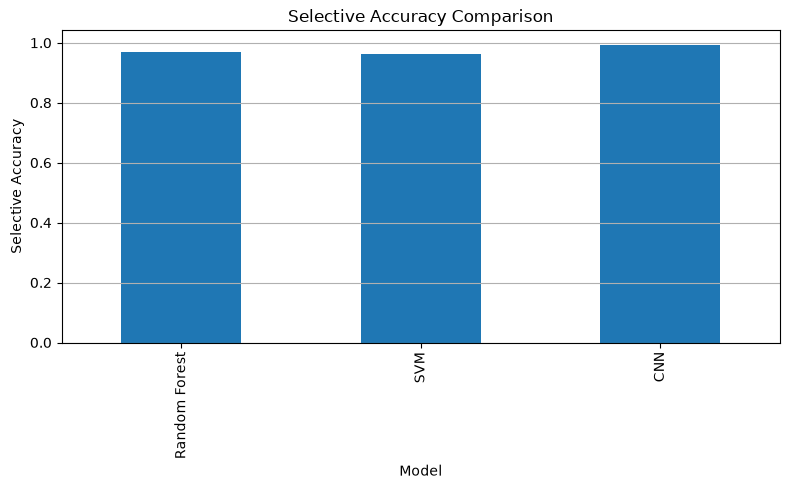

In [30]:
comparison.plot(

    x="Model",

    y="Accepted Accuracy",

    kind="bar",

    figsize=(8,5),

    legend=False

)

plt.ylabel("Selective Accuracy")

plt.title("Selective Accuracy Comparison")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [31]:
class_confidence.to_csv(

    RESULTS /

    "confidence_by_class.csv"

)

rejection_summary.to_csv(

    RESULTS /

    "rejection_by_class.csv"

)

comparison.to_csv(

    RESULTS /

    "unknown_detection_comparison.csv",

    index=False

)

print("Reports Saved Successfully")

Reports Saved Successfully


In [32]:
print("="*80)

print("UNKNOWN SIGNAL DETECTION SUMMARY")

print("="*80)

print()

print(

    f"Recommended Threshold : "

    f"{recommended_threshold:.2f}"

)

print()

print(

    f"Selective Accuracy : "

    f"{cnn_best['AcceptedAccuracy']*100:.2f}%"

)

print()

print(

    f"Accepted Samples : "

    f"{int(cnn_best['Accepted'])}"

)

print()

print(

    f"Rejected Samples : "

    f"{int(cnn_best['Rejected'])}"

)

print()

print(

    f"Rejection Rate : "

    f"{cnn_best['RejectionRate']*100:.2f}%"

)

print("="*80)

UNKNOWN SIGNAL DETECTION SUMMARY

Recommended Threshold : 0.50

Selective Accuracy : 99.20%

Accepted Samples : 8995

Rejected Samples : 5

Rejection Rate : 0.06%


In [33]:
summary = {

    "recommended_threshold":

        float(recommended_threshold),

    "accepted_accuracy":

        float(cnn_best["AcceptedAccuracy"]),

    "accepted_samples":

        int(cnn_best["Accepted"]),

    "rejected_samples":

        int(cnn_best["Rejected"]),

    "rejection_rate":

        float(cnn_best["RejectionRate"])

}

with open(

    RESULTS /

    "unknown_detection_summary.json",

    "w"

) as file:

    json.dump(

        summary,

        file,

        indent=4

    )

print("Summary Saved")

Summary Saved
